In [2]:
import pandas as pd
from pathlib import Path
import numpy as np

def load_wer(agent_path, kind):
    assert kind in ['heldout', 'test']
    results_path = agent_path / 'results' / f'wer_results_{kind}.csv'
    results = pd.read_csv(results_path, index_col=0)
    if kind == 'test':
        keys = ['F0', 'F1', 'F2', 'F3', 'M0', 'M1', 'M2', 'M3']
    else:
        keys = ['F4', 'F5', 'F6', 'F7', 'M4', 'M5', 'M6', 'M7']
    out = {}
    for key in keys:
        out[f'{key}_WER'] = 100*results[results.index.str.startswith(key)]['WER'].mean()
    out['WER'] = 100*results['WER'].mean()
    out['WER_per_spkr'] = [np.mean(out[f'{key}_WER']) for key in keys]
    return out
    
agent_folder = Path('/home/engaclew/agent/out/ssl_agent/cosine/8_speakers_6000_mn')

baseline = {}
for seed in range(0, 5):
    agent_path = agent_folder / f'8_speakers_6000_mn_mfcc_delta_delta2_cosine_seed_{seed}'
    results = load_wer(agent_path, kind='test')
    for key in results.keys():
        if key == 'WER_per_spkr':
            baseline[key] = results[key]
        elif key not in baseline:
            baseline[key] = [results[key]]
        else:
            baseline[key].append(results[key])

w2v = {f'layer_{i}': {} for i in range(0, 13)}
for seed in range(0, 1):
 for layer in range(0, 13):
     agent_path = agent_folder / f'8_speakers_6000_mn_layer_{layer}_cosine_seed_{seed}'
     results = load_wer(agent_path, kind='test')
     for key in results.keys():
         if key == 'WER_per_spkr':
             w2v[f'layer_{layer}'][key] = results[key]
         elif key not in w2v[f'layer_{layer}']:
             w2v[f'layer_{layer}'][key] = [results[key]]
         else:
             w2v[f'layer_{layer}'][key].append(results[key])

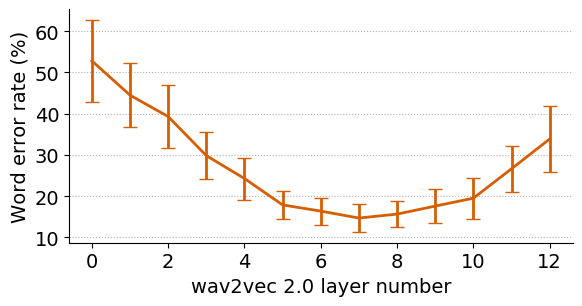

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import gridspec
import math
import numpy as np

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.serif'] = 'Arial'
matplotlib.rcParams.update({'font.size': 14, 'legend.handleheight':1, 'hatch.linewidth': 1.0,
                           'lines.markersize':5, 'lines.linewidth':2, 'errorbar.capsize': 5})

cm = 1/2.54
color = '#D55E00'
fig = plt.figure(figsize=(14.5*cm,7.5*cm), constrained_layout=True)
gs = gridspec.GridSpec(1, 4, figure=fig, height_ratios=[1])
ax = fig.add_subplot(gs[0, :])

key = 'WER_per_spkr'
X = range(0, 13)
Y = [np.mean(w2v[f'layer_{layer}'][key]) for layer in X]
Yerr = [np.std(w2v[f'layer_{layer}'][key], ddof=1) for layer in X]

ax.errorbar(X, Y, yerr=Yerr, linewidth=2, color=color)


#b = np.mean(baseline[key])
#ax.axhline(b)

ax.set_axisbelow(True)
ax.grid(visible=True, axis='y', linestyle=':', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Word error rate (%)')
ax.set_xlabel('wav2vec 2.0 layer number')
plt.savefig('/home/engaclew/agent/out/ssl_agent/wer_imitated_speech.png', dpi=300)
plt.show()

In [84]:
print(np.mean(baseline['WER_per_spkr']))

135.74984299199565
